In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def get_stock_data(ticker, period="1mo"):
    stock = yf.Ticker(ticker)
    data = stock.history(period=period)
    data = data[["Open", "High", "Low", "Close", "Volume"]]
    data.index = data.index.tz_localize(None)
    return data

In [3]:
df = get_stock_data("AAPL", period="1mo")
print(df.head())
print("\nShape:", df.shape)

                  Open        High         Low       Close    Volume
Date                                                                
2026-04-01  254.080002  256.179993  253.330002  255.630005  40059400
2026-04-02  254.199997  256.130005  250.649994  255.919998  31289400
2026-04-06  256.510010  262.160004  256.459991  258.859985  29329900
2026-04-07  256.160004  256.200012  245.699997  253.500000  62148000
2026-04-08  258.450012  259.750000  256.529999  258.899994  41032800

Shape: (21, 5)


In [4]:
def get_stock_info(ticker):
    stock = yf.Ticker(ticker)
    info = stock.info
    return {
        "Company": info.get("longName", "N/A"),
        "Sector": info.get("sector", "N/A"),
        "Industry": info.get("industry", "N/A"),
        "Market Cap": info.get("marketCap", "N/A"),
        "PE Ratio": info.get("trailingPE", "N/A"),
        "52W High": info.get("fiftyTwoWeekHigh", "N/A"),
        "52W Low": info.get("fiftyTwoWeekLow", "N/A"),
        "Current Price": info.get("currentPrice", "N/A")
    }

info = get_stock_info("AAPL")
for key, value in info.items():
    print(f"{key}: {value}")

Company: Apple Inc.
Sector: Technology
Industry: Consumer Electronics
Market Cap: 3983727394816
PE Ratio: 34.348103
52W High: 288.62
52W Low: 193.25
Current Price: 271.35


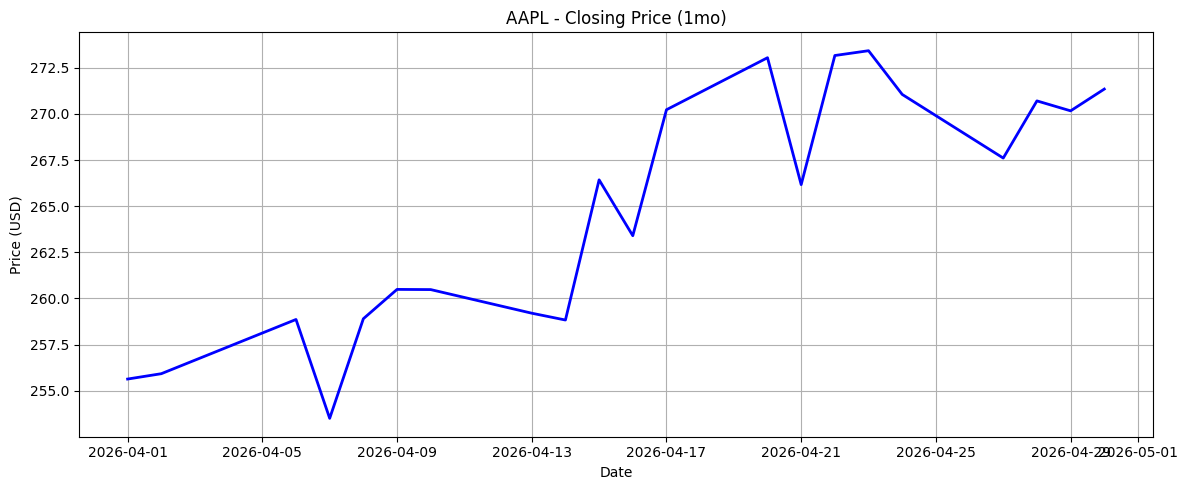

In [5]:
def plot_stock(ticker, period="1mo"):
    df = get_stock_data(ticker, period)
    
    plt.figure(figsize=(12, 5))
    plt.plot(df.index, df["Close"], color="blue", linewidth=2)
    plt.title(f"{ticker} - Closing Price ({period})")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_stock("AAPL", period="1mo")

In [6]:
# Test with multiple stocks
tickers = ["TSLA", "GOOGL", "MSFT"]

for ticker in tickers:
    info = get_stock_info(ticker)
    print(f"\n--- {ticker} ---")
    print(f"Company: {info['Company']}")
    print(f"Current Price: {info['Current Price']}")
    print(f"Market Cap: {info['Market Cap']}")
    print(f"PE Ratio: {info['PE Ratio']}")


--- TSLA ---
Company: Tesla, Inc.
Current Price: 381.63
Market Cap: 1433296830464
PE Ratio: 343.81082

--- GOOGL ---
Company: Alphabet Inc.
Current Price: 384.8
Market Cap: 4662022373376
PE Ratio: 29.329268

--- MSFT ---
Company: Microsoft Corporation
Current Price: 407.78
Market Cap: 3029167243264
PE Ratio: 24.27262
